In [1]:
# Import libraries
import pickle
import numpy as np
import anndata as ad
import pandas as pd
import scanpy as sc
import scipy
import scipy.sparse as sp 
import matplotlib.pyplot as plt
import anndata
from anndata import AnnData

# For plotting
import seaborn as sns

# For PCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# For umap
import umap

# SCVI
import scvi
import cellxgene_census
import cellxgene_census.experimental

# For ML training
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr
from scipy.sparse import issparse, vstack

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

/nfs/sw/easybuild/software/custom-conda/geneformer-1.0/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/nfs/home/aoku/.local/lib/python3.10/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_categorical_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


In [2]:
import sys
sys.path.append("/nfs/home/aoku/software/miniconda3/lib/python3.11/site-packages")

import harmonypy as hm

# Define plotting functions

In [3]:
def plot_true_vs_predicted(y_test_df, predicted_proportions, n_cols=4, figsize_per_plot=(3, 3), dot_size=5, save=False, title=""):

    # Get column names (cell types or lineages)
    cols = predicted_proportions.columns
    n_rows = int(np.ceil(len(cols) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * figsize_per_plot[0], n_rows * figsize_per_plot[1]))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        ax = axes[i]
        x = y_test_df[col]
        y = predicted_proportions[col]

        # Scatterplot
        sns.scatterplot(x=x, y=y, alpha=0.7, ax=ax, s=dot_size)

        # Identity line
        min_val = min(x.min(), y.min())
        max_val = max(x.max(), y.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--')

        # Correlation coefficient
        corr, _ = pearsonr(x, y)
        ax.text(
            0.05, 0.95, f"r = {corr:.2f}",
            transform=ax.transAxes,
            verticalalignment='top',
            fontsize=9,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.5)
        )

        # Titles and labels
        ax.set_title(f'{col}')
        ax.set_xlabel('True')
        ax.set_ylabel('Predicted')

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()

    if save:
        plt.savefig(f"{title}_plot.png", dpi=300, bbox_inches="tight")
    plt.show()


In [4]:
#sample_labels = ['B2-CZI08N'] * 1000 + ['B3-CZI11N'] * 1000 + ['B3-CZI05N'] * 1000 + ['test = B15-CZI251N'] * 1000
sample_labels = ['Sample 1'] * 1000 + ['Sample 2'] * 1000 + ['Sample 3'] * 1000 + ['Test = Sample 4'] * 1000
#sample_labels = ['Sample 1'] * 1000 + ['Sample 2'] * 1000 + ['Sample 3'] * 1000 + ['Sample 4'] * 1000 + ['Sample 5'] * 1000 + ['Sample 6'] * 1000 + ['Sample 7'] * 1000 + ['Sample 8'] * 1000 + ['Test = Sample 9'] * 1000

def plot_pca(train_df, test_df, sample_labels, n_components=2, title = "", dpi=300, save_path=""):

    # Add 'source' column
    train_df = train_df.copy()
    train_df['source'] = 'train'

    test_df = test_df.copy()
    test_df['source'] = 'test'

    # Merge train and test
    merged_df = pd.concat([train_df, test_df], ignore_index=True)

    # Assign sample labels
    if len(sample_labels) != merged_df.shape[0]:
        raise ValueError("Length of sample_labels must equal number of rows in merged_df")
    merged_df['sample'] = sample_labels

    # PCA input (exclude metadata)
    X = merged_df.drop(['source', 'sample'], axis=1)

    # PCA computation
    pca = PCA(n_components=n_components)
    principal_components = pca.fit_transform(X)

    # Create PCA DataFrame
    pca_df = pd.DataFrame(
        data=principal_components,
        columns=[f'PC{i+1}' for i in range(n_components)]
    )
    pca_df['sample'] = merged_df['sample']

    # Plot
    plt.figure(figsize=(6, 6))
    for sample in pca_df['sample'].unique():
        subset = pca_df[pca_df['sample'] == sample]
        plt.scatter(
            subset['PC1'],
            subset['PC2'],
            label=sample,
            alpha=0.7
        )

    plt.xlabel(f'PC 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)', fontsize=16)
    plt.ylabel(f'PC 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)', fontsize=16)
    #plt.title(title)
    #plt.legend()
    plt.legend(handlelength=0, frameon=False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.grid(False)
    plt.tight_layout()
    plt.savefig(save_path, dpi=dpi, bbox_inches="tight")
    plt.show()

In [5]:
pd.Series(sample_labels).value_counts()

Sample 1           1000
Sample 2           1000
Sample 3           1000
Test = Sample 4    1000
Name: count, dtype: int64

In [6]:
def run_rf_training(X, y, test, title=""):
    """
    Train RandomForestRegressor on training split, evaluate on test split,
    and predict on scvi_latent_czi_pseudobulk_test. Plots true vs predicted 
    correlations for both sets.

    Parameters
    ----------
    X : pd.DataFrame
        Latent feature representation (e.g., scVI pseudobulk embeddings).
    y : pd.DataFrame
        Corresponding cell proportions for samples.
    """

    # Split data into train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Train RF model
    model_rf = RandomForestRegressor(
        max_depth=20,
        max_features="sqrt",
        min_samples_leaf=1,
        min_samples_split=2,
        n_estimators=500,
        random_state=42
    )
    model_rf.fit(X_train, y_train)

    # Predict on held-out test set
    y_pred = model_rf.predict(X_test)
    predicted_proportions = pd.DataFrame(
        y_pred, columns=y_test.columns, index=X_test.index
    )

    # Plot correlation (pearson)
    plot_true_vs_predicted(y_test, predicted_proportions)

    # Predict on external test set (predefined globals)
    y_pred_test = model_rf.predict(test)
    predicted_proportions_test = pd.DataFrame(
        y_pred_test, columns=y_train.columns,
    )

    plot_true_vs_predicted(test_czi_cell_prop, predicted_proportions_test,save=True, title=title)

    return predicted_proportions, predicted_proportions_test

In [7]:
# def save_pca_plot(train_df, test_df, sample_labels, title="", save_path=None, dpi=300):
#     # Concatenate train + test
#     combined = pd.concat([train_df, test_df], axis=0)
    
#     # PCA
#     pca = PCA(n_components=2)
#     pca_result = pca.fit_transform(combined)
    
#     # Plot
#     plt.figure(figsize=(8, 6))
#     scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1],
#                           c=sample_labels, cmap="tab10", alpha=0.7, edgecolor="k")
#     plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% var)")
#     plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% var)")
#     plt.title(title)
#     plt.colorbar(scatter, label="Sample Labels")
#     plt.tight_layout()
    
#     if save_path:
#         plt.savefig(save_path, dpi=dpi, bbox_inches="tight")
#         print(f"Saved PCA plot to {save_path} (dpi={dpi})")
#     else:
#         plt.show()

In [8]:
def evaluate_predictions(y_true_df, y_pred_df):
    """
    Compute MAE, MSE, and RMSE per column between true and predicted values.

    Parameters
    ----------
    y_true_df : pd.DataFrame
        Ground truth cell proportions (rows = samples, cols = cell types).
    y_pred_df : pd.DataFrame
        Predicted cell proportions with same shape as y_true_df.

    Returns
    -------
    results_df : pd.DataFrame
        DataFrame containing per-cell-type MAE, MSE, and RMSE.
    """
    results = []
    for col in y_true_df.columns:
        y_true = y_true_df[col]
        y_pred = y_pred_df[col]

        mae = mean_absolute_error(y_true, y_pred)
        mse = mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)

        results.append({"Cell_Type": col, "MAE": mae, "MSE": mse, "RMSE": rmse})

    return pd.DataFrame(results)

In [9]:
def evaluate_overall_error(y_true_df, y_pred_df):
    """
    Compute overall MAE, MSE, and RMSE between true and predicted values.

    Parameters
    ----------
    y_true_df : pd.DataFrame
        Ground truth values (rows = samples, cols = features/cell types).
    y_pred_df : pd.DataFrame
        Predicted values with same shape/columns as y_true_df.

    Returns
    -------
    metrics : dict
        Dictionary containing MAE, MSE, RMSE.
    """
    y_true = y_true_df[y_pred_df.columns]

    mae = mean_absolute_error(y_true, y_pred_df)
    mse = mean_squared_error(y_true, y_pred_df)
    rmse = np.sqrt(mse)

    metrics = {"MAE": mae, "MSE": mse, "RMSE": rmse}

    return metrics

In [10]:
# Read cell type proportions (should be the same for both scVi and geneformer)
test_czi_cell_prop = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/test_pseudobulk_cell_prop.csv")
pseudobulk_czi_cell_prop = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/train_pseudobulk_cell_prop.csv")

In [11]:
pseudobulk_czi_cell_prop_plus = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/train_plus_pseudobulk_cell_prop.csv", index_col=0)

In [12]:
pseudobulk_czi_cell_prop_plus.head()

,Endothelial,Immune,Mesenchymal,Epithelial
0,0.4000,0.04375,0.38875,0.16750
1,0.0900,0.86000,0.03125,0.01875
2,0.2275,0.02625,0.68500,0.06125
3,0.2300,0.01500,0.17625,0.57875
4,0.2250,0.04625,0.50500,0.22375


# scVI based models

## scVI pre-trained on cxg

In [23]:
# Read scVI latent variables
scvi_latent_czi_pseudobulk = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/scVI_embed_train_set.csv", index_col=0)
scvi_latent_czi_pseudobulk_test = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/scVI_embed_test_set.csv", index_col=0)

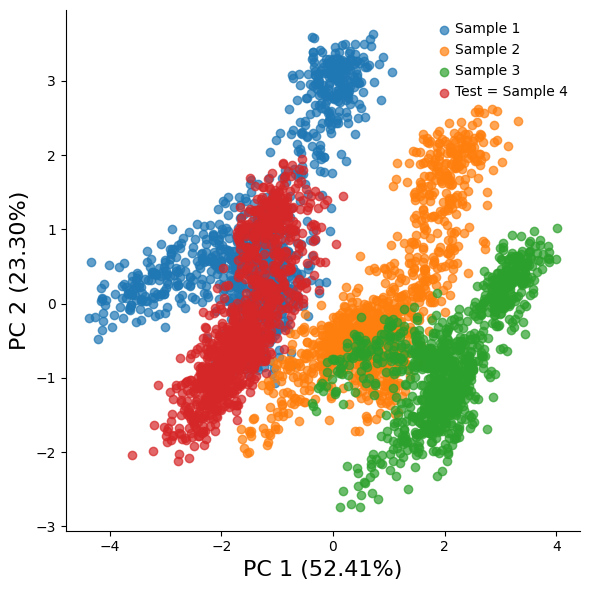

In [24]:
plot_pca(train_df = scvi_latent_czi_pseudobulk, 
         test_df = scvi_latent_czi_pseudobulk_test,
        sample_labels=sample_labels,
        title="Pre-trained scVI",
        save_path="../plots/pre_trained_scVI_with_legend.png")

In [11]:
# Split into train and test sets
X = scvi_latent_czi_pseudobulk
y = pseudobulk_czi_cell_prop

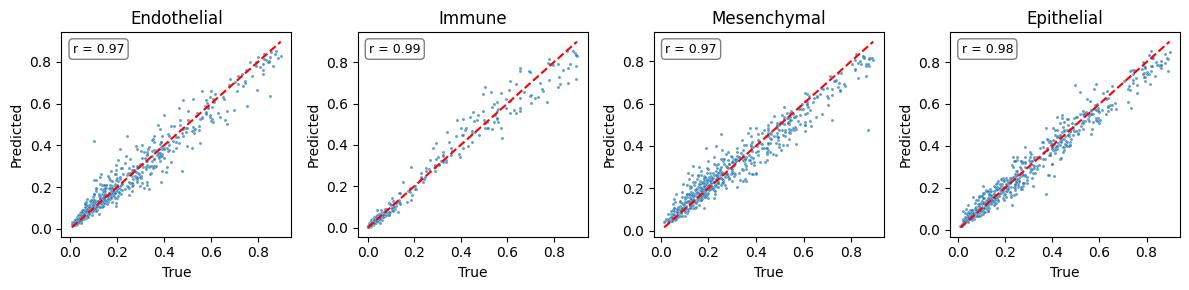

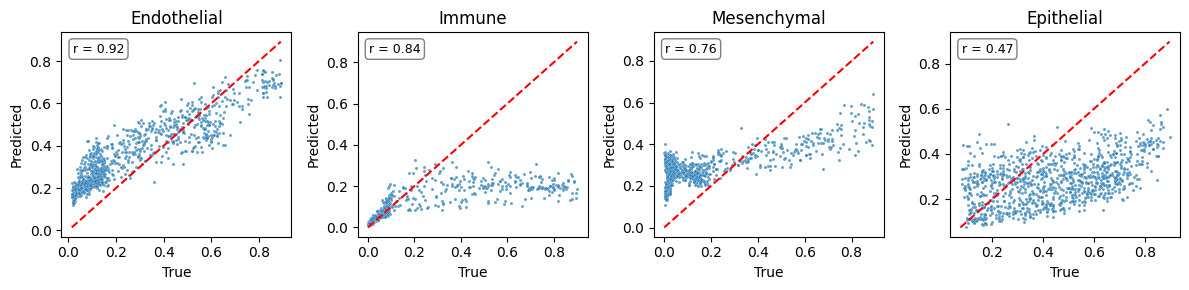

In [12]:
predicted_proportions_valid, predicted_proportions_test = run_rf_training(X = X, 
                                                                          y = y, 
                                                                          test=scvi_latent_czi_pseudobulk_test, title="scVI_pretrained")

In [13]:
evaluate_predictions(y_true_df=test_czi_cell_prop, y_pred_df = predicted_proportions_test)

,Cell_Type,MAE,MSE,RMSE
0,Epithelial,0.203468,0.058893,0.242678
1,Endothelial,0.131426,0.021017,0.144972
2,Mesenchymal,0.202826,0.048014,0.219120
3,Immune,0.093835,0.038956,0.197372


In [14]:
evaluate_overall_error(y_true_df=test_czi_cell_prop, y_pred_df = predicted_proportions_test)

{'MAE': 0.15788869236050931,
 'MSE': 0.04171974419192864,
 'RMSE': 0.20425411670742072}

## Trained scVI - 500 embed

In [39]:
# Read scVI latent variables
scvi_500 = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/scVI_with_batch_corr_dim_500_train_set.csv")
scVI_test_500 = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/scVI_with_batch_corr_dim_500_test_set.csv")

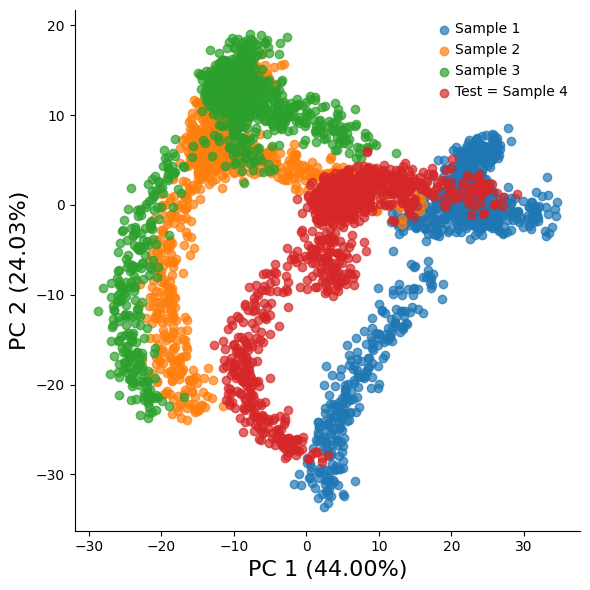

In [40]:
plot_pca(train_df = scvi_500, 
         test_df = scVI_test_500,
        sample_labels=sample_labels,
        title="scVI-500",
        save_path="../plots/trained_scVI.png")

In [41]:
# Split into train and test sets
X = scvi_500
y = pseudobulk_czi_cell_prop

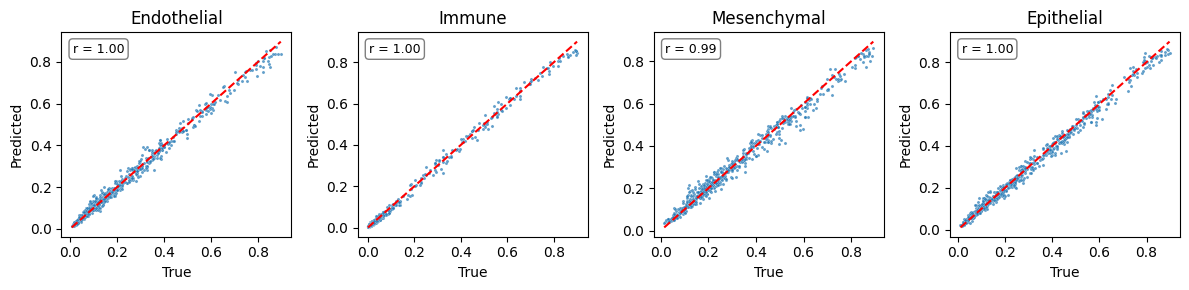

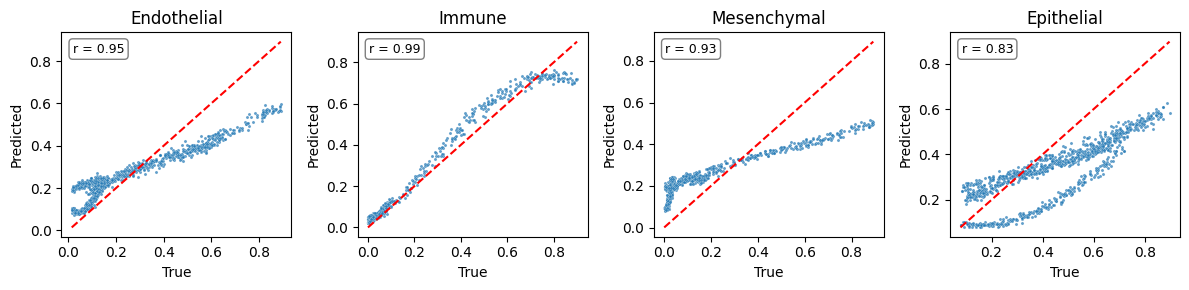

In [42]:
predicted_proportions_valid, predicted_proportions_test = run_rf_training(X = X, 
                                                                          y = y, test = scVI_test_500, title="scVI_500")

In [69]:
evaluate_overall_error(y_true_df=test_czi_cell_prop, y_pred_df = predicted_proportions_test)

{'MAE': 0.10593015875000006,
 'MSE': 0.017491463009154808,
 'RMSE': 0.13225529482464893}

# Geneformer based models

### Zero-shot Geneformer model

In [43]:
# Read scVI latent variables
gf_zero = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/train/gf_pseudobulk_train_set.csv", index_col=0)
gf_test_zero = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/test/gf_pseudobulk_test_set.csv", index_col=0)

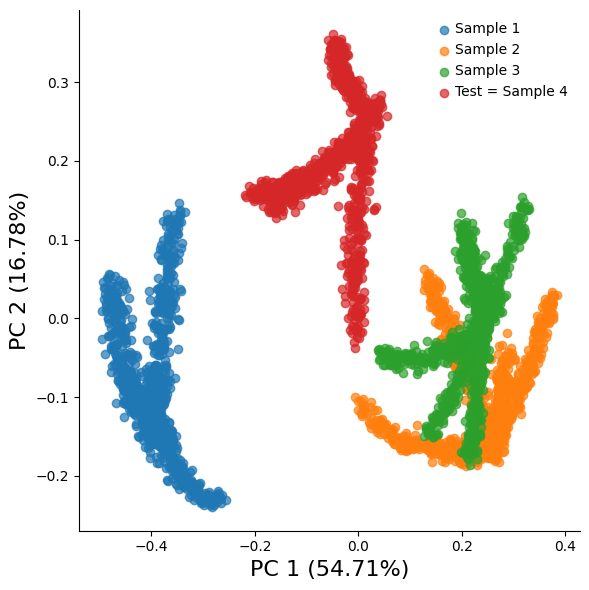

In [44]:
plot_pca(train_df = gf_zero, 
         test_df = gf_test_zero,
        sample_labels=sample_labels,
        title="zero_shot",
        save_path="../plots/zero_shot_gf.png")

In [45]:
# Split into train and test sets
X = gf_zero
y = pseudobulk_czi_cell_prop

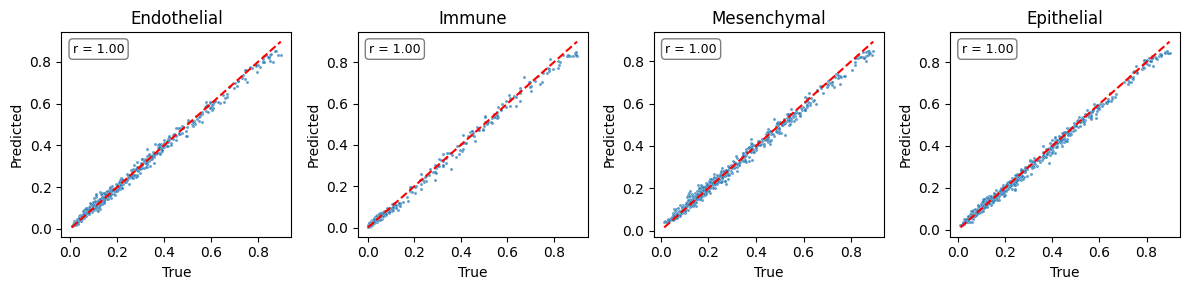

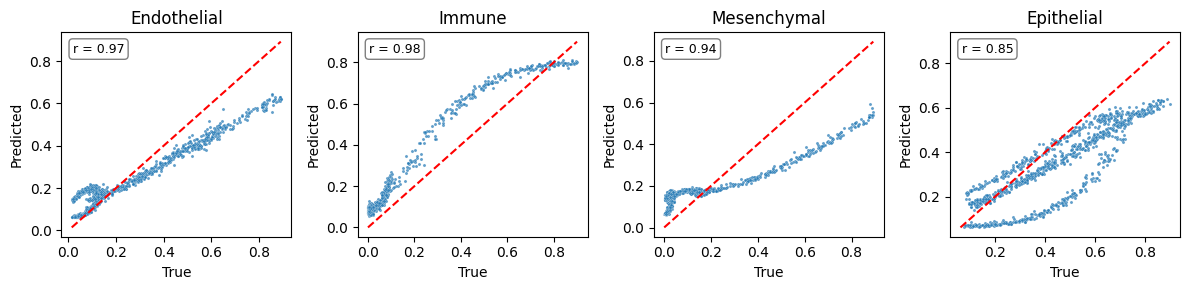

In [46]:
predicted_proportions_valid, predicted_proportions_test = run_rf_training(X = X, 
                                                                          y = y, test = gf_test_zero, title="gf_zero")

In [80]:
evaluate_overall_error(y_true_df=test_czi_cell_prop, y_pred_df = predicted_proportions_test)

{'MAE': 0.10144759487499996,
 'MSE': 0.015370315040415052,
 'RMSE': 0.12397707465662776}

### Finetuned Geneformer model

In [34]:
# Read scVI latent variables
gf_finetuned = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/train/gf_finetuned_pseudobulk_train_set.csv", index_col=0)
gf_test_finetuned = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/test/gf_finetuned_pseudobulk_test_set.csv", index_col=0)

In [36]:
plot_pca(train_df = gf_finetuned, 
         test_df = gf_test_finetuned,
        sample_labels=sample_labels,
        title="GF-fine-tuned",
        save_path="../plots/finetuned_geneformer.png")

In [50]:
# Split into train and test sets
X = gf_finetuned
y = pseudobulk_czi_cell_prop

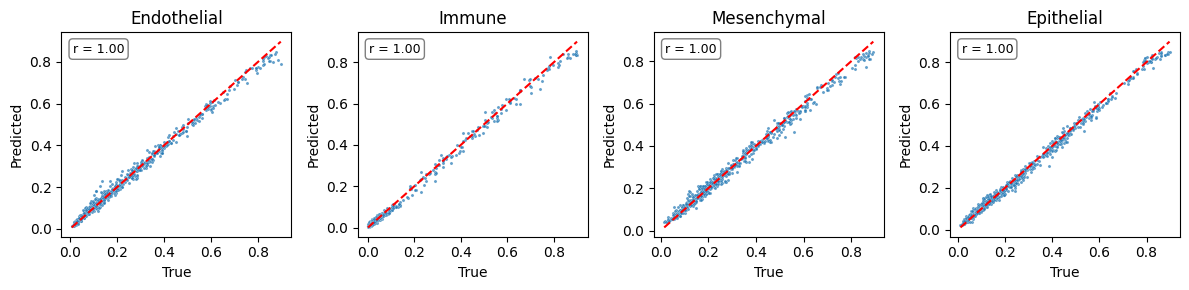

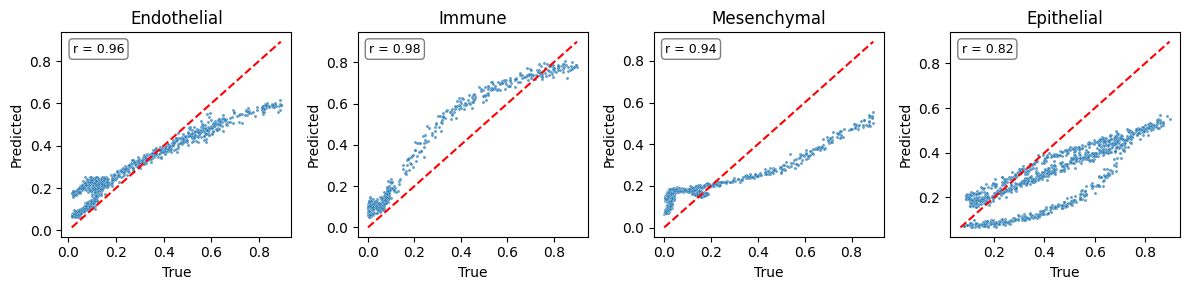

In [51]:
predicted_proportions_valid, predicted_proportions_test = run_rf_training(X = X, 
                                                                          y = y, test = gf_test_finetuned, title="gf_finetuned")

In [87]:
evaluate_overall_error(y_true_df=test_czi_cell_prop, y_pred_df = predicted_proportions_test)

{'MAE': 0.11172716553554787,
 'MSE': 0.018868355838391845,
 'RMSE': 0.13736213393214247}

### Geneformer more samples

In [15]:
# Read scVI latent variables
gf_plus = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/train/gf_zeroshot_plus_pseudobulk_train_set.csv", index_col=0)
gf_test_zero = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/test/gf_pseudobulk_test_set.csv", index_col=0)

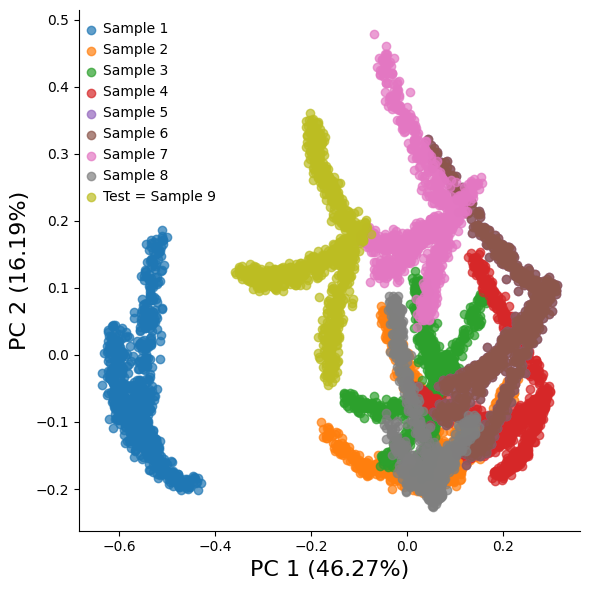

In [16]:
plot_pca(train_df = gf_plus, 
         test_df = gf_test_zero,
        sample_labels=sample_labels,
        title="zero_shot",
        save_path="../plots/zero_shot_gf_more_samples.png")

In [17]:
# Split into train and test sets
X = gf_plus
y = pseudobulk_czi_cell_prop_plus

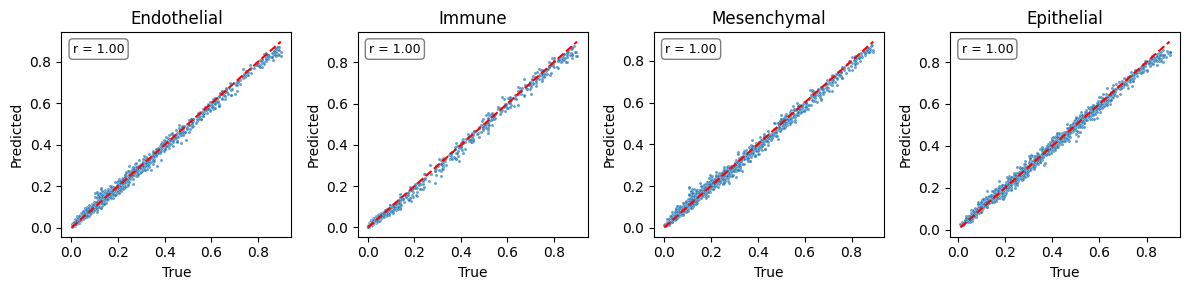

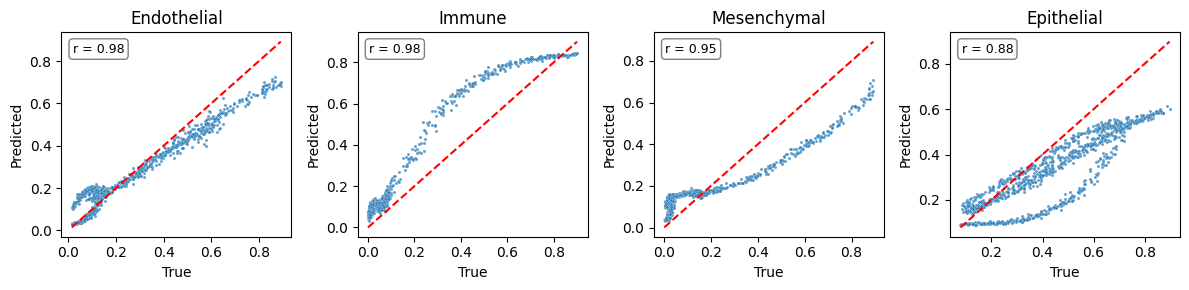

In [21]:
predicted_proportions_valid, predicted_proportions_test = run_rf_training(X = X, 
                                                                          y = y, test = gf_test_zero, title="gf_zero_more_samples")

In [22]:
evaluate_overall_error(y_true_df=test_czi_cell_prop, y_pred_df = predicted_proportions_test)

{'MAE': 0.09226874205289709,
 'MSE': 0.013461519428722247,
 'RMSE': 0.11602378820191249}

### Geneformer plus standard scaler

In [45]:
# Read scVI latent variables
gf_zero = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/train/gf_pseudobulk_train_set.csv", index_col=0)
gf_test_zero = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/test/gf_pseudobulk_test_set.csv", index_col=0)

In [50]:
# Initialize scaler
scaler = StandardScaler()

# Fit only on training data
gf_zero_scaled = scaler.fit_transform(gf_zero)

# Apply the same transformation to test data
gf_test_zero_scaled = scaler.transform(gf_test_zero)

# Convert back to DataFrame (keep same columns & index)
gf_zero_scaled = pd.DataFrame(gf_zero_scaled, index=gf_zero.index, columns=gf_zero.columns)
gf_test_zero_scaled = pd.DataFrame(gf_test_zero_scaled, index=gf_test_zero.index, columns=gf_test_zero.columns)

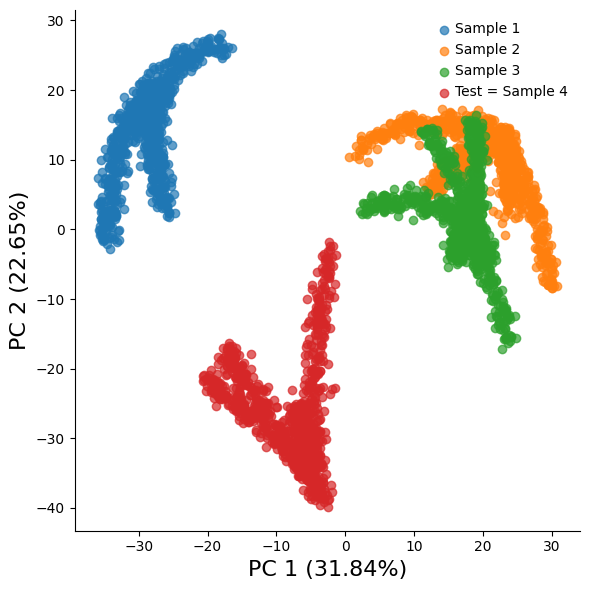

In [51]:
plot_pca(train_df = gf_zero_scaled, 
         test_df = gf_test_zero_scaled,
        sample_labels=sample_labels,
        title="gf_std_scaled",
        save_path="../plots/zero_shot_gf_std_scaled.png")

In [53]:
# Split into train and test sets
X = gf_zero_scaled
y = pseudobulk_czi_cell_prop

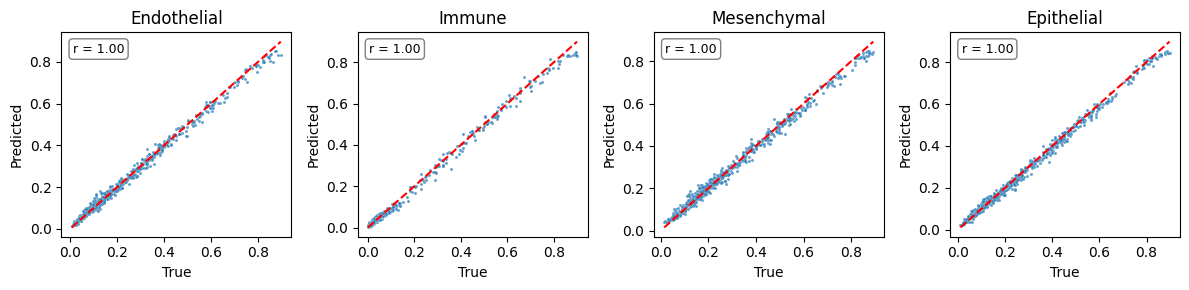

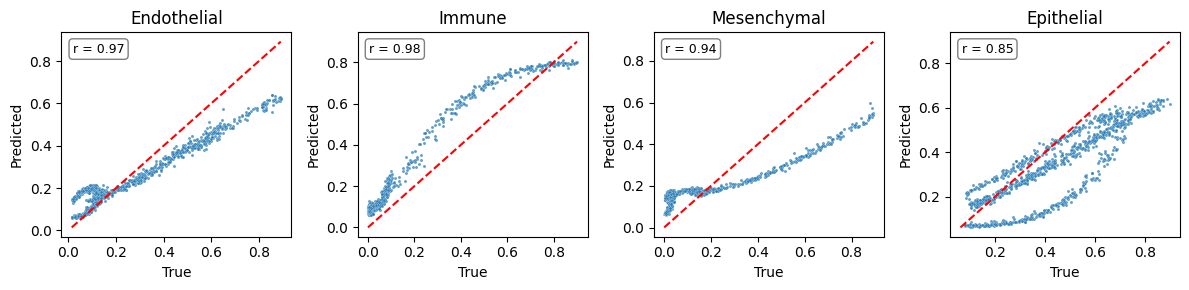

In [54]:
predicted_proportions_valid, predicted_proportions_test = run_rf_training(X = X, 
                                                                          y = y, test = gf_test_zero_scaled, title="gf_std_scaled")

In [55]:
evaluate_overall_error(y_true_df=test_czi_cell_prop, y_pred_df = predicted_proportions_test)

{'MAE': 0.10183850175000002,
 'MSE': 0.01545869599542437,
 'RMSE': 0.12433300444943961}

### Geneformer with Harmonypy

In [26]:
# Read scVI latent variables
gf_zero = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/train/gf_pseudobulk_train_set.csv", index_col=0)
gf_test_zero = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/test/gf_pseudobulk_test_set.csv", index_col=0)

In [37]:
# Merge data before running harmony
samples = ['Train1'] * 1000 + ['Train2'] * 1000 + ['Train3'] * 1000 + ['Test1'] * 1000
merged_df = pd.concat([gf_zero, gf_test_zero], ignore_index=True)
merged_df['sample'] = samples

# Run Harmony
vars_use = ["sample"]
ho = hm.run_harmony(merged_df.drop(['sample'], axis=1), merged_df, vars_use)

# Write the adjusted PCs to a new file.
res = pd.DataFrame(ho.Z_corr)
res = res.T
res.columns = ['{}'.format(i) for i in range(res.shape[1])]

2025-09-05 13:45:08,310 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-09-05 13:45:10,939 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-09-05 13:45:10,949 - harmonypy - INFO - Iteration 1 of 10
2025-09-05 13:45:12,342 - harmonypy - INFO - Iteration 2 of 10
2025-09-05 13:45:13,567 - harmonypy - INFO - Iteration 3 of 10
2025-09-05 13:45:14,893 - harmonypy - INFO - Converged after 3 iterations


In [31]:
# merge data
merged_df_harmony = res.copy()
#merged_df_harmony["source"] = merged_df["source"]

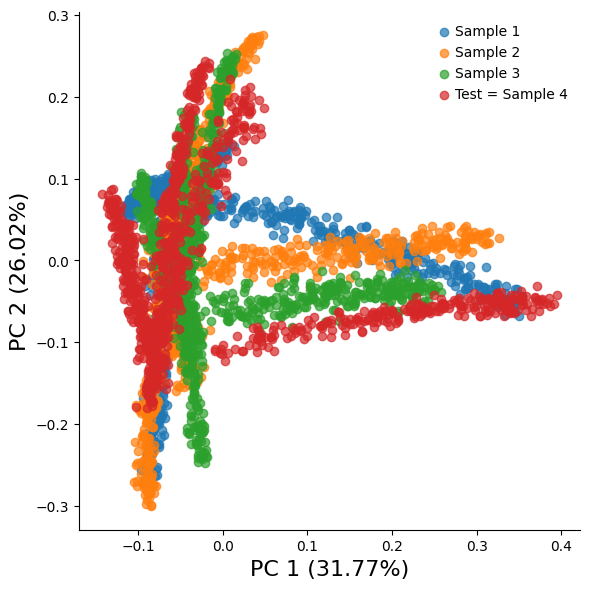

In [38]:
plot_pca(train_df = merged_df_harmony.iloc[0:3000, :], 
         test_df = merged_df_harmony.iloc[3000:4000, :],
        sample_labels=sample_labels,
        title="zero_shot",
        save_path="../plots/zero_shot_gf_harmony.png")

In [42]:
# Split into train and test sets
X = merged_df_harmony.iloc[0:3000, :]
y =  pseudobulk_czi_cell_prop

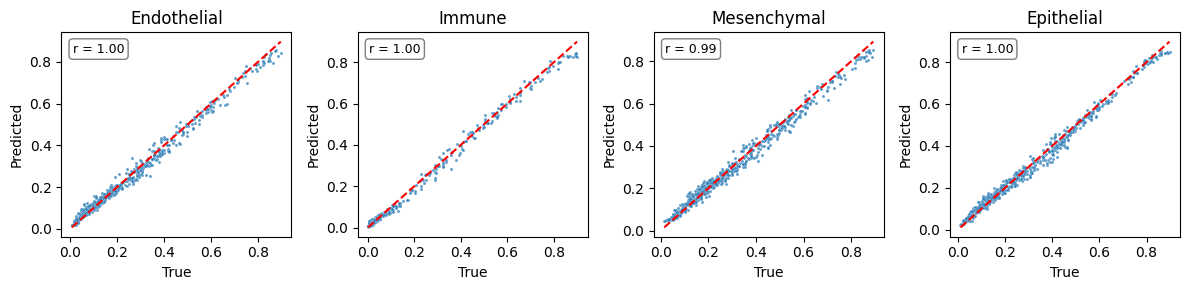

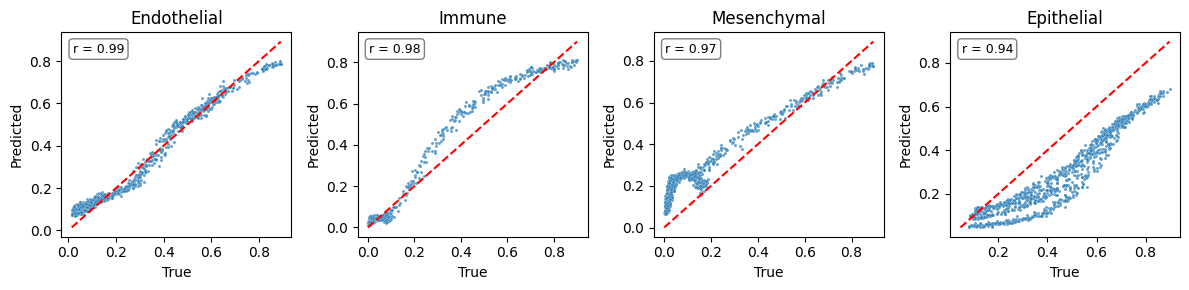

In [43]:
predicted_proportions_valid, predicted_proportions_test = run_rf_training(X = X, 
                                                                          y = y, 
                                                                          test = merged_df_harmony.iloc[3000:4000, :], 
                                                                          title="zero_shot_gf_harmony")

In [44]:
evaluate_overall_error(y_true_df=test_czi_cell_prop, y_pred_df = predicted_proportions_test)

{'MAE': 0.08786003119089852,
 'MSE': 0.013184571377593605,
 'RMSE': 0.11482408883850811}

# PCA based models

In [13]:
# Read in pseudbulks transform using PCA
train_pseudobulk_czi = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/pseudobulk_train_set.csv", index_col=0)
test_pseudobulk_czi = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/pseudobulk_test_set.csv")

In [36]:
train_test_merged = pd.concat([train_pseudobulk_czi, test_pseudobulk_czi], ignore_index=True)

In [41]:
# Standardize the data
scaler = StandardScaler()
#train_test_merged = scaler.fit_transform(train_test_merged)

# Run PCA
pca = PCA(n_components=10) 
pca_merged = pca.fit_transform(train_test_merged)

In [42]:
# transform to dataframe
pca_merged = pd.DataFrame(pca_merged)

In [43]:
# Split into train and test sets
X = pca_merged.iloc[0:3000, :]
y = pseudobulk_czi_cell_prop

# X = pd.DataFrame(pca.fit_transform(pca_merged.iloc[0:3000, :]))
# y = pseudobulk_czi_cell_prop

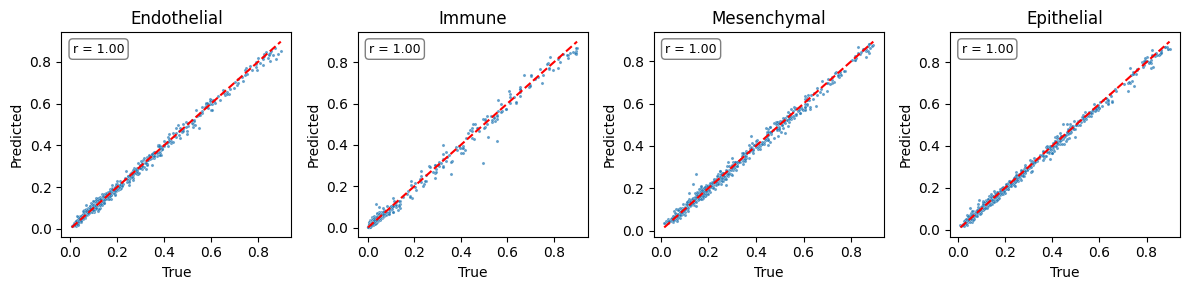

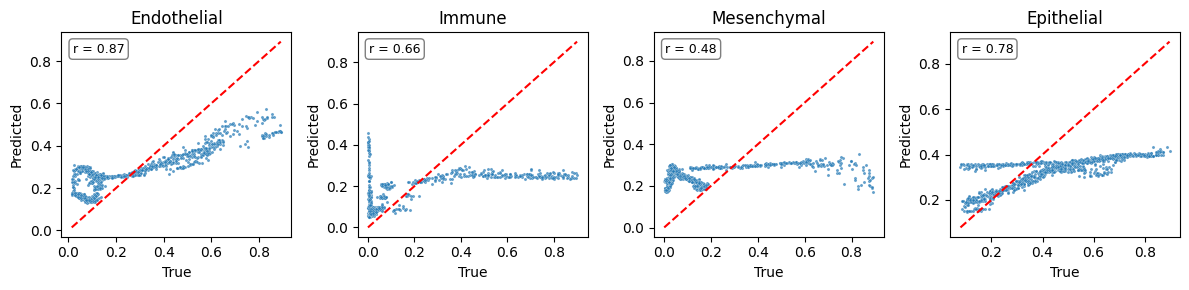

In [44]:
predicted_proportions_valid, predicted_proportions_test = run_rf_training(X = X, 
                                                                          y = y, test = pca_merged.iloc[3000:, ])

In [ ]:
# predicted_proportions_valid, predicted_proportions_test = run_rf_training(X = X, 
#                                                                           y = y, 
#                                                                           test = pd.DataFrame(pca.transform(pca_merged.iloc[3000:, ])))

In [64]:
evaluate_overall_error(y_true_df=test_czi_cell_prop, y_pred_df = predicted_proportions_test)

{'MAE': 0.1576793856919642,
 'MSE': 0.03891448906814997,
 'RMSE': 0.19726755705931467}

### GEX

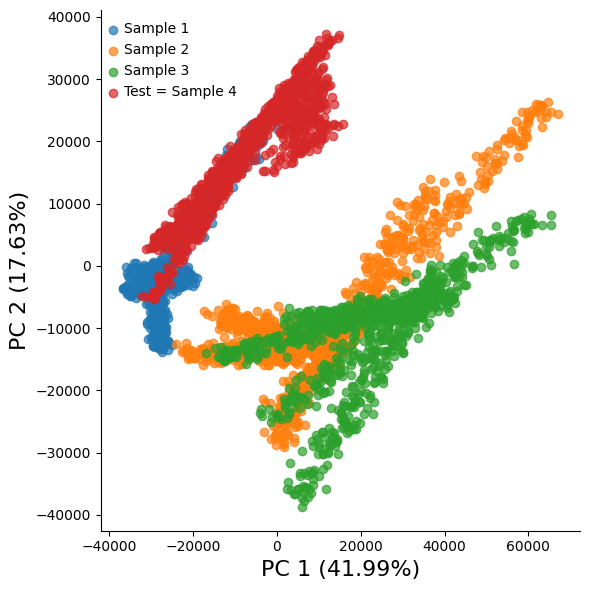

In [22]:
plot_pca(train_df = train_pseudobulk_czi, 
         test_df = test_pseudobulk_czi,
        sample_labels=sample_labels,
        title="GEX",
        save_path="../plots/GEX.png")

In [23]:
# Split into train and test sets
X = train_pseudobulk_czi
y = pseudobulk_czi_cell_prop

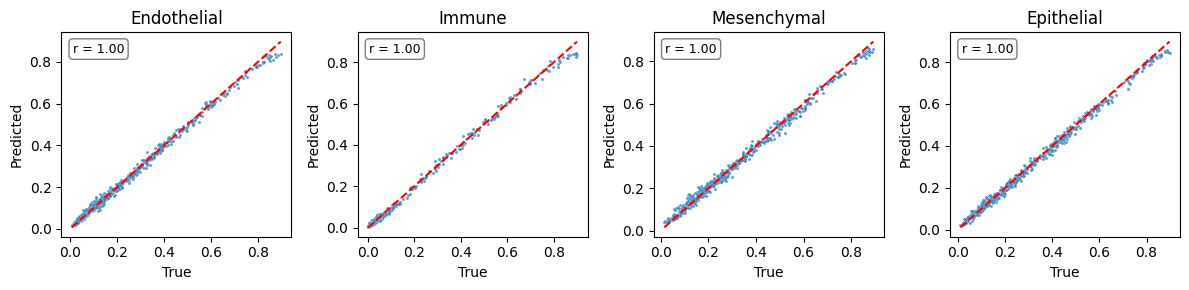

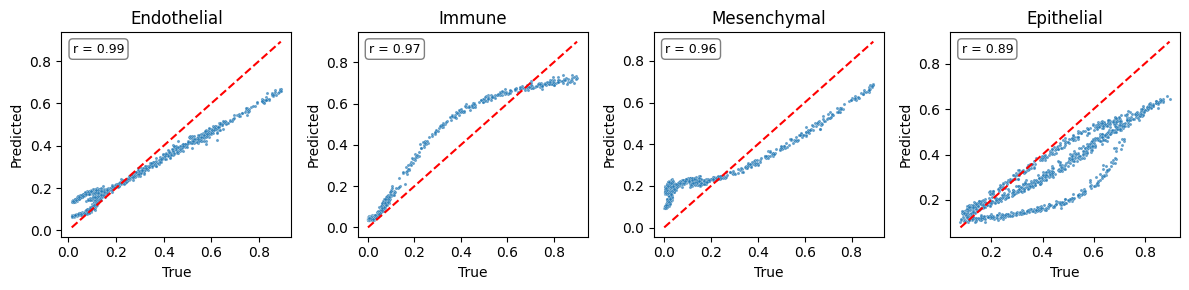

In [24]:
predicted_proportions_valid, predicted_proportions_test = run_rf_training(X = X, 
                                                                          y = y, test = test_pseudobulk_czi)

In [25]:
evaluate_overall_error(y_true_df=test_czi_cell_prop, y_pred_df = predicted_proportions_test)

{'MAE': 0.09235867916264015,
 'MSE': 0.013458719656507918,
 'RMSE': 0.11601172206509099}

### MuSiC

In [54]:
# Read music results
music_deconv = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/outputs/music_prop_pseudobulk_czi_vs_czi_single_cell_ref_estimated_heca_lineage_3_train_samples.csv",
                          index_col=0)
music_deconv.reset_index(drop=True, inplace=True)

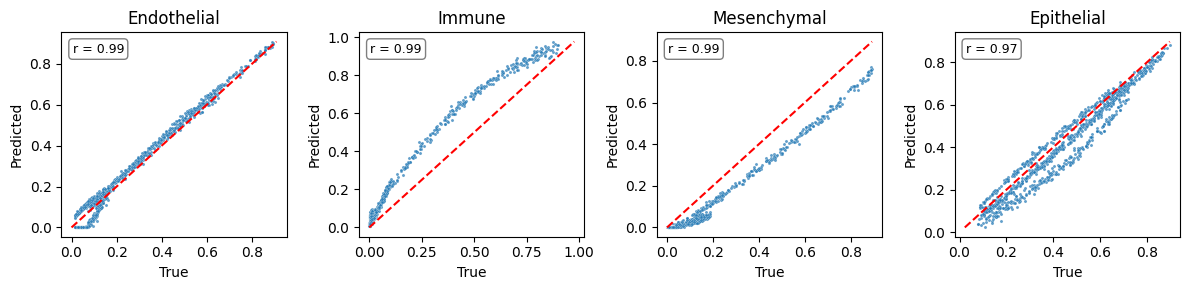

In [55]:
plot_true_vs_predicted(test_czi_cell_prop,music_deconv, save=True, title="music")

In [112]:
evaluate_overall_error(y_true_df=test_czi_cell_prop, y_pred_df = music_deconv)

{'MAE': 0.053562021962239664,
 'MSE': 0.004892747444931814,
 'RMSE': 0.06994817685209397}